<a href="https://colab.research.google.com/github/AnnaPaulaFigueiredo/data_master/blob/main/03_Pre_proc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [ ]:
import warnings
import shutil
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
from plotly.subplots import make_subplots

from google.colab import drive

from pyspark import StorageLevel

from pyspark.sql import SparkSession, DataFrame
from pyspark.sql import functions as F
from pyspark.sql.window import Window

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import functions as F
from pyspark.ml.functions import vector_to_array
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.sql.functions import (
    col,
    lit,
    concat,
    to_date
)

from pyspark.sql.types import (
    NumericType,
    DateType,
    TimestampType,
    StringType,
    DoubleType,
    FloatType
)

from pyspark.ml import Pipeline

from pyspark.ml.feature import (
    VectorAssembler,
    StringIndexer,
    OneHotEncoder
)
from pyspark.ml.stat import Correlation
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator,
    Evaluator
)

from pyspark.ml.tuning import (
    CrossValidator,
    ParamGridBuilder
)

from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", 500)
pd.set_option("display.float_format", "{:.2f}".format)

IDENTIFY = "msno"

if "spark" not in locals():
    spark = (
        SparkSession.builder
        .appName("DM_CASE")
        .getOrCreate()
    )

print("Spark:", spark.version)

spark.range(1).count()

print("SparkContext funcionando!")
print("Imports realizados com sucesso!")

Spark: 4.0.4
SparkContext funcionando!
Imports realizados com sucesso!


In [ ]:
ids = [
        "+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=",
        "++1G0wVY14Lp0VXak1ymLhPUdXPSFJVBnjWwzGxBKJs=",
        "+/SnlvpjhoCO8MTrd+iSyycIycNstDjPqBryBP+BQ+k=",
        "+/SdXkL2cLX5czSCaP78gkSQrV0J8vx7S4xZ90nTUOs=",
        "++1G0wVY14Lp0VXak1ymLhPUdXPSFJVBnjWwzGxBKJs="
        ]


# Treino Teste e Validação


201601-201607 -> Treino
202608 -> Teste
202609 -> Validation

In [ ]:
%time
output_path =  "/content/drive/MyDrive/SANTANDER/master.parquet"

dfs_master = spark.read.parquet(output_path)
dfs_master.limit(2).show(truncate=False)

CPU times: user 3 µs, sys: 1e+03 ns, total: 4 µs
Wall time: 8.58 µs
+--------------------------------------------+------+-------------+----------------------+----+---+-------+--------------+--------+----------------------+-------------+-----------+-----------+--------+-------------------+------+------+------+-------+-------+-------+------------------+---------+-----------+------------------+-------------------+------------------+------------------+-------------------+-------------------+-------------------+---------------------+---------------+-----------+------------+--------------+-----------------+-----------------+-----------------+---------------+------------------+-------------+----------------------+---------+-----------------------+-------------+-----------+-------------+-------------+---------------+--------------------------+-------------------+--------------------+---------------------+
|msno                                        |safra |safra_date_m3|registration_init_time

In [ ]:
%time
dfs_master = dfs_master.withColumn(
    "dataset_type",
    F.when((F.col("safra") >= 201601) & (F.col("safra") <= 201607), F.lit("train"))
     .when(F.col("safra") == 201608, F.lit("test"))
     .when(F.col("safra") == 201609, F.lit("validation"))
     .otherwise(F.lit("unknown"))
)


# Ordem desejada
ordem = (
    F.when(F.col("dataset_type") == "train", 1)
     .when(F.col("dataset_type") == "test", 2)
     .when(F.col("dataset_type") == "validation", 3)
     .otherwise(99)
)

# MSNOs únicos por dataset
df_dist = (
    dfs_master
    .groupBy("dataset_type")
    .agg(
        F.countDistinct("msno").alias("qtd_msno_unicos"),
        F.count("*").alias("qtd_linhas")
    )
)

dfs_master_train = (
    dfs_master
    .filter(
        F.col("dataset_type") == "train"
    )
)

dfs_master_test = (
    dfs_master
    .filter(
        F.col("dataset_type") == "test"
    )
)

dfs_master_validacao = (
    dfs_master
    .filter(
        F.col("dataset_type") == "validation"
    )
)

print("TRAIN      :", f"{dfs_master_train.count():,}")
print("TEST       :", f"{dfs_master_test.count():,}")
print("VALIDAÇÃO  :", f"{dfs_master_validacao.count():,}")

# Total de MSNOs únicos
total_msno = dfs_master.select("msno").distinct().count()

resultado = (
    df_dist
    .withColumn(
        "perc_msno_unicos",
        F.round(
            F.col("qtd_msno_unicos") / F.lit(total_msno) * 100,
            2
        )
    )
    .withColumn("ordem", ordem)
    .orderBy("ordem")
    .drop("ordem")
)

resultado.show()

CPU times: user 5 µs, sys: 0 ns, total: 5 µs
Wall time: 8.82 µs
TRAIN      : 6,008,027
TEST       : 959,754
VALIDAÇÃO  : 976,722
+------------+---------------+----------+----------------+
|dataset_type|qtd_msno_unicos|qtd_linhas|perc_msno_unicos|
+------------+---------------+----------+----------------+
|       train|        1166116|   6008027|           90.49|
|        test|         959754|    959754|           74.48|
|  validation|         976722|    976722|           75.79|
+------------+---------------+----------+----------------+



# Inputs


## Not Transactions

In [ ]:
def adicionar_flag_sem_transacao(df):

    return (
        df
        .withColumn(
            "flag_sem_transacao_m0",
            F.when(
                F.col("ticket_medio").isNull(),
                1
            ).otherwise(0)
        )
    )

def adicionar_flag_sem_historico_transacao(df):

    return (
        df
        .withColumn(
            "flag_sem_historico_transacao",
            F.when(
                F.col("delta_receita").isNull(),
                1
            ).otherwise(0)
        )
    )

def tratar_flag_historico_logs(df):

    return (
        df
        .withColumn(
            "flag_historico_uso_m1",
            F.coalesce(
                F.col("flag_historico_uso_m1"),
                F.lit(0)
            )
        )
    )

In [ ]:
dfs_master_train = adicionar_flag_sem_transacao(
    dfs_master_train
)

dfs_master_test = adicionar_flag_sem_transacao(
    dfs_master_test
)

dfs_master_validacao = adicionar_flag_sem_transacao(
    dfs_master_validacao
)

dfs_master_train.groupBy(
    "flag_sem_transacao_m0"
).count().orderBy(
    "flag_sem_transacao_m0"
).show()

+---------------------+-------+
|flag_sem_transacao_m0|  count|
+---------------------+-------+
|                    0|4775404|
|                    1|1232623|
+---------------------+-------+



In [ ]:
dfs_master_train = adicionar_flag_sem_historico_transacao(
    dfs_master_train
)

dfs_master_test = adicionar_flag_sem_historico_transacao(
    dfs_master_test
)

dfs_master_validacao = adicionar_flag_sem_historico_transacao(
    dfs_master_validacao
)

(
    dfs_master_train
    .groupBy(
        "flag_sem_transacao_m0",
        "flag_sem_historico_transacao"
    )
    .count()
    .orderBy(
        "flag_sem_transacao_m0",
        "flag_sem_historico_transacao"
    )
    .show()
)

+---------------------+----------------------------+-------+
|flag_sem_transacao_m0|flag_sem_historico_transacao|  count|
+---------------------+----------------------------+-------+
|                    0|                           0|4629060|
|                    0|                           1| 146344|
|                    1|                           1|1232623|
+---------------------+----------------------------+-------+



In [ ]:
dfs_master_train = tratar_flag_historico_logs(
    dfs_master_train
)

dfs_master_test = tratar_flag_historico_logs(
    dfs_master_test
)

dfs_master_validacao = tratar_flag_historico_logs(
    dfs_master_validacao
)

dfs_master_train.groupBy(
    "flag_historico_uso_m1"
).count().show()

+---------------------+-------+
|flag_historico_uso_m1|  count|
+---------------------+-------+
|                    1|5289005|
|                    0| 719022|
+---------------------+-------+



## Input Fill 0

In [ ]:
zero_fill_cols = [
    "actual_amount_paid",
    "is_auto_renew",
    "is_cancel",
    "tem_observacao_anterior",
    "upgrade_plano",
    "downgrade_plano",
    "flag_gap_transacoes",
    "ticket_medio"
]

def preencher_zero(df, colunas):

    for coluna in colunas:

        if coluna in df.columns:

            df = df.withColumn(
                coluna,
                F.coalesce(
                    F.col(coluna),
                    F.lit(0)
                )
            )

    return df

dfs_master_train = preencher_zero(
    dfs_master_train,
    zero_fill_cols
)

dfs_master_test = preencher_zero(
    dfs_master_test,
    zero_fill_cols
)

dfs_master_validacao = preencher_zero(
    dfs_master_validacao,
    zero_fill_cols
)

for coluna in zero_fill_cols:

    print(
        coluna,
        "→",
        dfs_master_train.filter(
            F.col(coluna).isNull()
        ).count(),
        "nulls"
    )

actual_amount_paid → 0 nulls
is_auto_renew → 0 nulls
is_cancel → 0 nulls
tem_observacao_anterior → 0 nulls
upgrade_plano → 0 nulls
downgrade_plano → 0 nulls
flag_gap_transacoes → 0 nulls
ticket_medio → 0 nulls


In [ ]:
for coluna in zero_fill_cols:

    print(
        coluna,
        "→",
        dfs_master_test.filter(
            F.col(coluna).isNull()
        ).count(),
        "nulls"
    )

actual_amount_paid → 0 nulls
is_auto_renew → 0 nulls
is_cancel → 0 nulls
tem_observacao_anterior → 0 nulls
upgrade_plano → 0 nulls
downgrade_plano → 0 nulls
flag_gap_transacoes → 0 nulls
ticket_medio → 0 nulls


In [ ]:
for coluna in zero_fill_cols:

    print(
        coluna,
        "→",
        dfs_master_validacao.filter(
            F.col(coluna).isNull()
        ).count(),
        "nulls"
    )

actual_amount_paid → 0 nulls
is_auto_renew → 0 nulls
is_cancel → 0 nulls
tem_observacao_anterior → 0 nulls
upgrade_plano → 0 nulls
downgrade_plano → 0 nulls
flag_gap_transacoes → 0 nulls
ticket_medio → 0 nulls


## Input Median

In [ ]:
median_cols = [
    "payment_plan_days",
    "plan_list_price",
    "delta_receita",
    "var_receita",
    "intervalo_transacoes_meses",
    "taxa_auto_renew_hist"
]

medianas_train = {}

for coluna in median_cols:

    if coluna in dfs_master_train.columns:

        mediana = (
            dfs_master_train
            .approxQuantile(
                coluna,
                [0.5],
                0.01
            )[0]
        )

        medianas_train[coluna] = mediana

        print(
            f"{coluna:<30} → "
            f"mediana TRAIN = {mediana}"
        )

payment_plan_days              → mediana TRAIN = 30.0
plan_list_price                → mediana TRAIN = 149.0
delta_receita                  → mediana TRAIN = 0.0
var_receita                    → mediana TRAIN = 0.0
intervalo_transacoes_meses     → mediana TRAIN = 1.0
taxa_auto_renew_hist           → mediana TRAIN = 1.0


In [ ]:
def preencher_medianas(df, medianas):

    for coluna, valor in medianas.items():

        df = df.withColumn(
            coluna,
            F.coalesce(
                F.col(coluna),
                F.lit(float(valor))
            )
        )

    return df

In [ ]:
dfs_master_train = preencher_medianas(
    dfs_master_train,
    medianas_train
)

dfs_master_test = preencher_medianas(
    dfs_master_test,
    medianas_train
)

dfs_master_validacao = preencher_medianas(
    dfs_master_validacao,
    medianas_train
)

## Input payment_id

In [ ]:
def tratar_payment_method(df):

    return (
        df
        .withColumn(
            "payment_method_id",
            F.coalesce(
                F.col("payment_method_id").cast("string"),
                F.lit("missing")
            )
        )
    )

dfs_master_train = tratar_payment_method(
    dfs_master_train
)

dfs_master_test = tratar_payment_method(
    dfs_master_test
)

dfs_master_validacao = tratar_payment_method(
    dfs_master_validacao
)

## Dias até a Expiração

In [ ]:
def criar_features_expiracao(df):

    return (
        df

        # Diferença bruta entre expiração e safra
        .withColumn(
            "dias_ate_expiracao_bruto",
            F.when(
                F.col("membership_expire_date").isNotNull(),
                F.datediff(
                    F.col("membership_expire_date"),
                    F.col("safra_date_dt")
                )
            )
        )

        # Informação de expiração desconhecida
        .withColumn(
            "flag_expiracao_desconhecida",
            F.when(
                F.col("membership_expire_date").isNull(),
                1
            ).otherwise(0)
        )

        # Indicador de assinatura já expirada
        .withColumn(
            "flag_assinatura_expirada",
            F.when(
                F.col("membership_expire_date").isNotNull() &
                (
                    F.col("membership_expire_date")
                    < F.col("safra_date_dt")
                ),
                1
            ).otherwise(0)
        )

        # Dias até expiração
        .withColumn(
            "dias_ate_expiracao",
            F.when(
                F.col("membership_expire_date").isNull(),
                None
            )
            .when(
                F.col("membership_expire_date") < F.col("safra_date_dt"),
                0
            )
            .otherwise(
                F.datediff(
                    F.col("membership_expire_date"),
                    F.col("safra_date_dt")
                )
            )
        )
    )
dfs_master_train = criar_features_expiracao(
    dfs_master_train
)

dfs_master_test = criar_features_expiracao(
    dfs_master_test
)

dfs_master_validacao = criar_features_expiracao(
    dfs_master_validacao
)

mediana_dias_expiracao = (
    dfs_master_train
    .approxQuantile(
        "dias_ate_expiracao",
        [0.5],
        0.01
    )[0]
)

print("Mediana TRAIN - dias_expiracao:", mediana_dias_expiracao)

Mediana TRAIN - dias_expiracao: 47.0


In [ ]:
(
    dfs_master_train
    .groupBy(
        "flag_expiracao_desconhecida",
        "flag_assinatura_expirada"
    )
    .agg(
        F.count("*").alias("clientes"),
        F.avg("dias_ate_expiracao").alias("media_dias"),
        F.expr(
            "percentile_approx(dias_ate_expiracao, 0.5)"
        ).alias("mediana_dias"),
        F.avg("churn_m3").alias("taxa_churn")
    )
    .orderBy(
        "flag_expiracao_desconhecida",
        "flag_assinatura_expirada"
    )
    .show(truncate=False)
)

+---------------------------+------------------------+--------+-----------------+------------+-------------------+
|flag_expiracao_desconhecida|flag_assinatura_expirada|clientes|media_dias       |mediana_dias|taxa_churn         |
+---------------------------+------------------------+--------+-----------------+------------+-------------------+
|0                          |0                       |4775109 |50.59114168912165|47          |0.10229672244130972|
|0                          |1                       |295     |0.0              |0           |0.8135593220338984 |
|1                          |0                       |1232623 |NULL             |NULL        |0.30226273564585443|
+---------------------------+------------------------+--------+-----------------+------------+-------------------+



In [ ]:
for nome in ["dfs_master_train", "dfs_master_test", "dfs_master_validacao"]:

    df = globals()[nome]

    df = df.withColumn(
        "dias_ate_expiracao",
        F.coalesce(
            F.col("dias_ate_expiracao"),
            F.lit(float(mediana_dias_expiracao))
        )
    )

    globals()[nome] = df

dfs_master_train = dfs_master_train.drop("membership_expire_date")
dfs_master_test = dfs_master_test.drop("membership_expire_date")
dfs_master_validacao = dfs_master_validacao.drop("membership_expire_date")

## Input Mudança Preço

In [ ]:
dfs_master_train = dfs_master_train.withColumn(
    "mudanca_preco",
    F.coalesce(
        F.col("mudanca_preco"),
        F.lit(0.0)
    )
)

dfs_master_test = dfs_master_test.withColumn(
    "mudanca_preco",
    F.coalesce(
        F.col("mudanca_preco"),
        F.lit(0.0)
    )
)

dfs_master_validacao = dfs_master_validacao.withColumn(
    "mudanca_preco",
    F.coalesce(
        F.col("mudanca_preco"),
        F.lit(0.0)
    )
)

## Verify Nulls

In [ ]:
def verificar_nulls(df, nome):

    print("=" * 70)
    print(f"NULLS — {nome}")
    print("=" * 70)

    nulls = []

    for coluna in df.columns:

        qtd = (
            df
            .filter(F.col(coluna).isNull())
            .count()
        )

        if qtd > 0:
            nulls.append(
                (coluna, qtd)
            )

    if not nulls:

        print("✓ Nenhum NULL encontrado.")

    else:

        for coluna, qtd in nulls:

            print(
                f"{coluna:<35} "
                f"{qtd:,}"
            )

    return nulls

In [ ]:
nulls_train = verificar_nulls(
    dfs_master_train,
    "TRAIN"
)

nulls_test = verificar_nulls(
    dfs_master_test,
    "TEST"
)

nulls_validacao = verificar_nulls(
    dfs_master_validacao,
    "VALIDAÇÃO"
)

NULLS — TRAIN
dias_ate_expiracao_bruto            1,232,623
NULLS — TEST
dias_ate_expiracao_bruto            128,758
NULLS — VALIDAÇÃO
dias_ate_expiracao_bruto            124,266


## Input Inconsistentes - Age

In [ ]:
def analisar_bd(
    df: DataFrame,
    nome_dataset: str = "DATASET",
    piso_idade: int = 14,
    teto_idade: int = 100,
    fator_iqr: float = 1.5
):
    """
    Analisa a variável bd (idade).

    Esta função NÃO altera o DataFrame.
    Ela serve apenas para diagnóstico da variável.

    Regras de negócio:
    - válida: > 14 e <= 100
    - ruído / piso: <= 14
    - acima do teto: > 100

    Também calcula:
    - Q1
    - mediana
    - Q3
    - IQR
    - limites IQR
    - média
    - moda
    """

    print("=" * 75)
    print(f"📊 ANÁLISE DE OUTLIERS - VARIÁVEL BD | {nome_dataset}")
    print("=" * 75)

    # ------------------------------------------------------------
    # 1. Total
    # ------------------------------------------------------------

    total = df.count()

    # Cast 'bd' to integer type for numerical operations
    df_numeric_bd = df.withColumn("bd_numeric", F.col("bd").cast("integer"))

    # ------------------------------------------------------------
    # 2. Quantidade de valores válidos
    # ------------------------------------------------------------

    qtd_validos = (
        df_numeric_bd
        .filter(
            (F.col("bd_numeric") > piso_idade) &
            (F.col("bd_numeric") <= teto_idade)
        )
        .count()
    )

    # ------------------------------------------------------------
    # 3. Valores considerados ruído / piso
    # ------------------------------------------------------------

    qtd_piso = (
        df_numeric_bd
        .filter(F.col("bd_numeric") <= piso_idade)
        .count()
    )

    # ------------------------------------------------------------
    # 4. Valores acima do teto
    # ------------------------------------------------------------

    qtd_acima_teto = (
        df_numeric_bd
        .filter(F.col("bd_numeric") > teto_idade)
        .count()
    )

    # ------------------------------------------------------------
    # 5. Quartis
    #
    # IMPORTANTE:
    # Os quartis são calculados sobre os valores válidos.
    # ------------------------------------------------------------

    quantis = (
        df_numeric_bd
        .filter(
            (F.col("bd_numeric") > piso_idade) &
            (F.col("bd_numeric") <= teto_idade)
        )
        .approxQuantile(
            "bd_numeric",
            [0.25, 0.50, 0.75],
            0.01
        )
    )

    q1 = quantis[0]
    mediana = quantis[1]
    q3 = quantis[2]

    # ------------------------------------------------------------
    # 6. IQR
    # ------------------------------------------------------------

    iqr = q3 - q1

    limite_inferior_iqr = q1 - fator_iqr * iqr
    limite_superior_iqr = q3 + fator_iqr * iqr

    # ------------------------------------------------------------
    # 7. Outliers pelo critério IQR
    #
    # Novamente, somente entre valores válidos.
    # ------------------------------------------------------------

    qtd_outliers_iqr_inferiores = (
        df_numeric_bd
        .filter(
            (F.col("bd_numeric") > piso_idade) &
            (F.col("bd_numeric") <= teto_idade) &
            (F.col("bd_numeric") < limite_inferior_iqr)
        )
        .count()
    )

    qtd_outliers_iqr_superiores = (
        df_numeric_bd
        .filter(
            (F.col("bd_numeric") > piso_idade) &
            (F.col("bd_numeric") <= teto_idade) &
            (F.col("bd_numeric") > limite_superior_iqr)
        )
        .count()
    )

    # ------------------------------------------------------------
    # 8. Média
    #
    # Mantida apenas para análise.
    # NÃO será utilizada para imputação.
    # ------------------------------------------------------------

    media = (
        df_numeric_bd
        .filter(
            (F.col("bd_numeric") > piso_idade) &
            (F.col("bd_numeric") <= teto_idade)
        )
        .agg(F.avg("bd_numeric"))
        .first()[0]
    )

    # ------------------------------------------------------------
    # 9. Moda
    #
    # Mantida apenas para análise.
    # NÃO será utilizada para imputação.
    # ------------------------------------------------------------

    moda_row = (
        df_numeric_bd
        .filter(
            (F.col("bd_numeric") > piso_idade) &
            (F.col("bd_numeric") <= teto_idade)
        )
        .groupBy("bd_numeric")
        .count()
        .orderBy(
            F.desc("count"),
            F.asc("bd_numeric")
        )
        .first()
    )

    moda = moda_row["bd_numeric"] if moda_row else None

    # ------------------------------------------------------------
    # 10. Percentuais
    # ------------------------------------------------------------

    pct_validos = (qtd_validos / total * 100) if total else 0
    pct_piso = (qtd_piso / total * 100) if total else 0
    pct_acima_teto = (qtd_acima_teto / total * 100) if total else 0

    # ------------------------------------------------------------
    # 11. Exibição
    # ------------------------------------------------------------

    print(f"População analisada : {nome_dataset}")
    print(f"Total               : {total:,}")
    print("-" * 75)

    print(
        f"Válidos (>{piso_idade} e <={teto_idade})"
        f" | {qtd_validos:>12,} | {pct_validos:>7.2f}%"
    )

    print(
        f"Ruído / piso (<={piso_idade})"
        f"            | {qtd_piso:>12,} | {pct_piso:>7.2f}%"
    )

    print(
        f"Acima do teto (>{teto_idade})"
        f"           | {qtd_acima_teto:>12,} | {pct_acima_teto:>7.2f}%"
    )

    print(
        f"Outliers IQR inferiores"
        f"             | {qtd_outliers_iqr_inferiores:>12,}"
        f" | {qtd_outliers_iqr_inferiores / total * 100:>7.2f}%"
    )

    print(
        f"Outliers IQR superiores"
        f"             | {qtd_outliers_iqr_superiores:>12,}"
        f" | {qtd_outliers_iqr_superiores / total * 100:>7.2f}%"
    )

    print("-" * 75)

    print(f"Q1                         : {q1:.2f}")
    print(f"Mediana                    : {mediana:.2f}")
    print(f"Q3                         : {q3:.2f}")
    print(f"IQR                        : {iqr:.2f}")
    print(f"Limite inferior IQR        : {limite_inferior_iqr:.2f}")
    print(f"Limite superior IQR        : {limite_superior_iqr:.2f}")
    print(f"Piso de negócio            : {piso_idade}")
    print(f"Teto de negócio            : {teto_idade}")
    print(f"Média                      : {media:.2f}")
    print(f"Moda                       : {moda:.2f}")

    print("=" * 75)

    return {
        "Q1": q1,
        "mediana": mediana,
        "Q3": q3,
        "IQR": iqr,
        "limite_inferior_iqr": limite_inferior_iqr,
        "limite_superior_iqr": limite_superior_iqr,
        "media": media,
        "moda": moda,
        "fator_iqr": fator_iqr,
        "piso_idade": piso_idade,
        "teto_idade": teto_idade,
        "total": total,
        "qtd_validos": qtd_validos,
        "qtd_piso": qtd_piso,
        "qtd_acima_teto": qtd_acima_teto,
        "qtd_outliers_iqr_inferiores": qtd_outliers_iqr_inferiores,
        "qtd_outliers_iqr_superiores": qtd_outliers_iqr_superiores
    }
def imputar_bd_mediana(
    df: DataFrame,
    mediana_bd: int,
    piso_idade: int = 14,
    teto_idade: int = 100
):
    """
    Trata a variável bd utilizando exclusivamente a mediana
    das idades válidas calculada no TRAIN.

    Regras:
    - > 14 e <= 100 → mantém valor original
    - <= 14 → mediana
    - > 100 → mediana
    - NULL → mediana
    - cria flag_bd_imputado
    - bd final é inteiro
    """

    # ------------------------------------------------------------
    # 1. Garantir que a mediana seja inteira
    # ------------------------------------------------------------

    mediana_bd = int(round(mediana_bd))

    print("=" * 75)
    print("🔧 IMPUTAÇÃO DA VARIÁVEL BD")
    print("=" * 75)

    print(f"Mediana utilizada : {mediana_bd}")

    # ------------------------------------------------------------
    # 2. Criar flag ANTES da imputação
    #
    # 1 = valor original inválido/nulo
    # 0 = idade válida
    # ------------------------------------------------------------

    df = df.withColumn(
        "flag_bd_imputado",
        F.when(
            F.col("bd").isNull() |
            (F.col("bd") <= piso_idade) |
            (F.col("bd") > teto_idade),
            1
        ).otherwise(0)
    )

    # ------------------------------------------------------------
    # 3. Imputar pela mediana
    # ------------------------------------------------------------

    df = df.withColumn(
        "bd",
        F.when(
            (F.col("bd") > piso_idade) &
            (F.col("bd") <= teto_idade),
            F.col("bd")
        )
        .otherwise(
            F.lit(mediana_bd)
        )
    )

    # ------------------------------------------------------------
    # 4. Garantir tipo inteiro
    # ------------------------------------------------------------

    df = df.withColumn(
        "bd",
        F.col("bd").cast("int")
    )

    # ------------------------------------------------------------
    # 5. Estatísticas da imputação
    # ------------------------------------------------------------

    qtd_imputados = (
        df
        .filter(F.col("flag_bd_imputado") == 1)
        .count()
    )

    qtd_nao_imputados = (
        df
        .filter(F.col("flag_bd_imputado") == 0)
        .count()
    )

    print(f"Registros mantidos : {qtd_nao_imputados:,}")
    print(f"Registros imputados: {qtd_imputados:,}")
    print(f"Mediana utilizada  : {mediana_bd}")
    print("Tipo final de bd   : IntegerType")

    print("=" * 75)

    return df

In [ ]:
analise_bd_train = analisar_bd(
    dfs_master_train,
    nome_dataset="TRAIN"
)

# Mediana calculada somente sobre idades válidas
mediana_bd_train = int(
    round(analise_bd_train["mediana"])
)

print(
    f"\nMediana válida do TRAIN para imputação: "
    f"{mediana_bd_train}"
)

📊 ANÁLISE DE OUTLIERS - VARIÁVEL BD | TRAIN
População analisada : TRAIN
Total               : 6,008,027
---------------------------------------------------------------------------
Válidos (>14 e <=100) |    3,258,837 |   54.24%
Ruído / piso (<=14)            |    2,745,569 |   45.70%
Acima do teto (>100)           |        3,621 |    0.06%
Outliers IQR inferiores             |            0 |    0.00%
Outliers IQR superiores             |       93,591 |    1.56%
---------------------------------------------------------------------------
Q1                         : 24.00
Mediana                    : 29.00
Q3                         : 35.00
IQR                        : 11.00
Limite inferior IQR        : 7.50
Limite superior IQR        : 51.50
Piso de negócio            : 14
Teto de negócio            : 100
Média                      : 30.18
Moda                       : 27.00

Mediana válida do TRAIN para imputação: 29


In [ ]:
dfs_master_train = imputar_bd_mediana(
    dfs_master_train,
    mediana_bd=mediana_bd_train
)

dfs_master_test = imputar_bd_mediana(
    dfs_master_test,
    mediana_bd=mediana_bd_train
)

dfs_master_validacao = imputar_bd_mediana(
    dfs_master_validacao,
    mediana_bd=mediana_bd_train
)

🔧 IMPUTAÇÃO DA VARIÁVEL BD
Mediana utilizada : 29
Registros mantidos : 3,258,837
Registros imputados: 2,749,190
Mediana utilizada  : 29
Tipo final de bd   : IntegerType
🔧 IMPUTAÇÃO DA VARIÁVEL BD
Mediana utilizada : 29
Registros mantidos : 494,993
Registros imputados: 464,761
Mediana utilizada  : 29
Tipo final de bd   : IntegerType
🔧 IMPUTAÇÃO DA VARIÁVEL BD
Mediana utilizada : 29
Registros mantidos : 492,368
Registros imputados: 484,354
Mediana utilizada  : 29
Tipo final de bd   : IntegerType


# New Variables

## Perfil

In [ ]:
def calcular_thresholds_consumo(
    df_train: DataFrame
) -> dict:
    """
    ============================================================
    CALCULA THRESHOLDS DOS PERFIS COMPORTAMENTAIS
    ============================================================

    Os thresholds são calculados EXCLUSIVAMENTE no TRAIN.

    Depois de calculados, os mesmos valores devem ser utilizados
    em TRAIN, TEST e VALIDATION.

    ============================================================
    NOVA ARQUITETURA
    ============================================================

    A arquitetura atual NÃO utiliza mais variáveis de 3 meses.

    Variáveis utilizadas:

    VOLUME
        total_plays
        -> quantidade total de reproduções no M0

    FREQUÊNCIA
        ativo_log
        -> quantidade de dias com atividade no M0

    DIVERSIDADE
        diversidade_ratio
        -> relação entre músicas únicas e volume de consumo

    SKIP
        skip_ratio
        -> proporção de reproduções interrompidas/puladas

    ============================================================
    RETORNO
    ============================================================

    dict contendo os percentis P25, P50 e P75 calculados
    exclusivamente no TRAIN.
    """

    print("=" * 75)
    print("THRESHOLDS DOS PERFIS COMPORTAMENTAIS")
    print("=" * 75)
    print("Base utilizada: TRAIN")
    print("Regra: thresholds calculados somente no TRAIN")
    print("=" * 75)

    # ============================================================
    # 1. VOLUME - TOTAL DE PLAYS
    # ============================================================

    percentis_volume = (
        df_train
        .select("total_plays")
        .where(
            F.col("total_plays").isNotNull()
        )
        .stat
        .approxQuantile(
            "total_plays",
            [0.25, 0.50, 0.75],
            0.01
        )
    )

    p25_volume = percentis_volume[0]
    p50_volume = percentis_volume[1]
    p75_volume = percentis_volume[2]

    # ============================================================
    # 2. FREQUÊNCIA - DIAS ATIVOS
    # ============================================================

    percentis_frequencia = (
        df_train
        .select("ativo_log")
        .where(
            F.col("ativo_log").isNotNull()
        )
        .stat
        .approxQuantile(
            "ativo_log",
            [0.25, 0.50, 0.75],
            0.01
        )
    )

    p25_frequencia = percentis_frequencia[0]
    p50_frequencia = percentis_frequencia[1]
    p75_frequencia = percentis_frequencia[2]

    # ============================================================
    # 3. DIVERSIDADE
    # ============================================================

    percentis_diversidade = (
        df_train
        .select("diversidade_ratio")
        .where(
            F.col("diversidade_ratio").isNotNull()
        )
        .stat
        .approxQuantile(
            "diversidade_ratio",
            [0.25, 0.50, 0.75],
            0.01
        )
    )

    p25_diversidade = percentis_diversidade[0]
    p50_diversidade = percentis_diversidade[1]
    p75_diversidade = percentis_diversidade[2]

    # ============================================================
    # 4. SKIP
    # ============================================================

    percentis_skip = (
        df_train
        .select("skip_ratio")
        .where(
            F.col("skip_ratio").isNotNull()
        )
        .stat
        .approxQuantile(
            "skip_ratio",
            [0.25, 0.50, 0.75],
            0.01
        )
    )

    p25_skip = percentis_skip[0]
    p50_skip = percentis_skip[1]
    p75_skip = percentis_skip[2]

    # ============================================================
    # 5. ORGANIZA THRESHOLDS
    # ============================================================

    thresholds = {

        # Volume
        "total_plays_p25": p25_volume,
        "total_plays_p50": p50_volume,
        "total_plays_p75": p75_volume,

        # Frequência
        "ativo_log_p25": p25_frequencia,
        "ativo_log_p50": p50_frequencia,
        "ativo_log_p75": p75_frequencia,

        # Diversidade
        "diversidade_ratio_p25": p25_diversidade,
        "diversidade_ratio_p50": p50_diversidade,
        "diversidade_ratio_p75": p75_diversidade,

        # Skip
        "skip_ratio_p25": p25_skip,
        "skip_ratio_p50": p50_skip,
        "skip_ratio_p75": p75_skip
    }

    # ============================================================
    # 6. EXIBE RESULTADOS
    # ============================================================

    print("\nVOLUME - total_plays")
    print(f"  P25: {p25_volume:.2f}")
    print(f"  P50: {p50_volume:.2f}")
    print(f"  P75: {p75_volume:.2f}")

    print("\nFREQUÊNCIA - ativo_log")
    print(f"  P25: {p25_frequencia:.2f}")
    print(f"  P50: {p50_frequencia:.2f}")
    print(f"  P75: {p75_frequencia:.2f}")

    print("\nDIVERSIDADE - diversidade_ratio")
    print(f"  P25: {p25_diversidade:.4f}")
    print(f"  P50: {p50_diversidade:.4f}")
    print(f"  P75: {p75_diversidade:.4f}")

    print("\nSKIP - skip_ratio")
    print(f"  P25: {p25_skip:.4f}")
    print(f"  P50: {p50_skip:.4f}")
    print(f"  P75: {p75_skip:.4f}")

    print("\n" + "=" * 75)

    return thresholds

def criar_perfis_consumo(
    df: DataFrame,
    thresholds: dict
) -> DataFrame:
    """
    ============================================================
    CRIA PERFIS COMPORTAMENTAIS
    ============================================================

    Utiliza os thresholds previamente calculados no TRAIN.

    IMPORTANTE:
        Esta função NÃO calcula novos thresholds.

        Portanto, deve receber o mesmo dicionário de thresholds
        para TRAIN, TEST e VALIDATION.

    ============================================================
    NOVA ARQUITETURA
    ============================================================

    PERFIL DE VOLUME
        Baseado em total_plays no M0.

    PERFIL DE FREQUÊNCIA
        Baseado em ativo_log no M0.

    PERFIL DE CONSUMO
        Combinação de volume + frequência.

    PERFIL DE ENGAJAMENTO
        Combinação de diversidade_ratio + skip_ratio.

    ============================================================
    SAÍDA
    ============================================================

    Adiciona:

        perfil_volume
        perfil_frequencia
        perfil_consumo
        perfil_engajamento
    """

    # ============================================================
    # 1. RECUPERA THRESHOLDS
    # ============================================================

    # Volume
    p25_volume = thresholds["total_plays_p25"]
    p50_volume = thresholds["total_plays_p50"]
    p75_volume = thresholds["total_plays_p75"]

    # Frequência
    p25_frequencia = thresholds["ativo_log_p25"]
    p50_frequencia = thresholds["ativo_log_p50"]
    p75_frequencia = thresholds["ativo_log_p75"]

    # Diversidade
    p25_diversidade = thresholds["diversidade_ratio_p25"]
    p50_diversidade = thresholds["diversidade_ratio_p50"]
    p75_diversidade = thresholds["diversidade_ratio_p75"]

    # Skip
    p25_skip = thresholds["skip_ratio_p25"]
    p50_skip = thresholds["skip_ratio_p50"]
    p75_skip = thresholds["skip_ratio_p75"]

    # ============================================================
    # 2. PERFIL DE VOLUME
    # ============================================================
    #
    # total_plays representa o volume de consumo no M0.
    #
    # Classificação baseada nos quartis calculados no TRAIN:
    #
    # <= P25       -> baixo
    # <= P50       -> médio
    # <= P75       -> alto
    # > P75        -> muito alto
    #
    # ============================================================

    df = df.withColumn(
        "perfil_volume",

        F.when(
            F.col("total_plays").isNull(),
            "sem_historico"
        )

        .when(
            F.col("total_plays") <= p25_volume,
            "baixo"
        )

        .when(
            F.col("total_plays") <= p50_volume,
            "medio"
        )

        .when(
            F.col("total_plays") <= p75_volume,
            "alto"
        )

        .otherwise(
            "muito_alto"
        )
    )

    # ============================================================
    # 3. PERFIL DE FREQUÊNCIA
    # ============================================================
    #
    # ativo_log representa quantos dias o cliente utilizou
    # o serviço durante o M0.
    #
    # ============================================================

    df = df.withColumn(
        "perfil_frequencia",

        F.when(
            F.col("ativo_log").isNull() |
            (F.col("ativo_log") == 0),
            "sem_atividade"
        )

        .when(
            F.col("ativo_log") <= p25_frequencia,
            "raro"
        )

        .when(
            F.col("ativo_log") <= p50_frequencia,
            "regular"
        )

        .when(
            F.col("ativo_log") <= p75_frequencia,
            "frequente"
        )

        .otherwise(
            "muito_frequente"
        )
    )

    # ============================================================
    # 4. PERFIL DE CONSUMO
    # ============================================================
    #
    # Combina:
    #
    #   volume
    #   +
    #   frequência
    #
    # para criar uma visão mais interpretável do comportamento.
    #
    # ============================================================

    df = df.withColumn(
        "perfil_consumo",

        # --------------------------------------------------------
        # Ausência de informação
        # --------------------------------------------------------

        F.when(
            F.col("perfil_volume") == "sem_historico",
            "sem_historico"
        )

        .when(
            F.col("perfil_frequencia") == "sem_atividade",
            "sem_atividade"
        )

        # --------------------------------------------------------
        # Muito alto volume
        # --------------------------------------------------------

        .when(
            (F.col("perfil_volume") == "muito_alto") &
            F.col("perfil_frequencia").isin(
                "frequente",
                "muito_frequente"
            ),
            "heavy_regular"
        )

        .when(
            (F.col("perfil_volume") == "muito_alto") &
            F.col("perfil_frequencia").isin(
                "raro",
                "regular"
            ),
            "heavy_sporadic"
        )

        # --------------------------------------------------------
        # Alto volume
        # --------------------------------------------------------

        .when(
            (F.col("perfil_volume") == "alto") &
            F.col("perfil_frequencia").isin(
                "frequente",
                "muito_frequente"
            ),
            "heavy_regular"
        )

        .when(
            (F.col("perfil_volume") == "alto") &
            (F.col("perfil_frequencia") == "regular"),
            "regular"
        )

        .when(
            (F.col("perfil_volume") == "alto") &
            (F.col("perfil_frequencia") == "raro"),
            "casual_sporadic"
        )

        # --------------------------------------------------------
        # Volume médio
        # --------------------------------------------------------

        .when(
            (F.col("perfil_volume") == "medio") &
            F.col("perfil_frequencia").isin(
                "frequente",
                "muito_frequente"
            ),
            "regular"
        )

        .when(
            (F.col("perfil_volume") == "medio") &
            (F.col("perfil_frequencia") == "regular"),
            "casual_regular"
        )

        .when(
            (F.col("perfil_volume") == "medio") &
            (F.col("perfil_frequencia") == "raro"),
            "casual_sporadic"
        )

        # --------------------------------------------------------
        # Baixo volume
        # --------------------------------------------------------

        .when(
            (F.col("perfil_volume") == "baixo") &
            F.col("perfil_frequencia").isin(
                "frequente",
                "muito_frequente"
            ),
            "light_regular"
        )

        .when(
            (F.col("perfil_volume") == "baixo") &
            (F.col("perfil_frequencia") == "regular"),
            "light_regular"
        )

        .when(
            (F.col("perfil_volume") == "baixo") &
            (F.col("perfil_frequencia") == "raro"),
            "rare"
        )

        .otherwise(
            "unknown"
        )
    )

    # ============================================================
    # 5. PERFIL DE ENGAJAMENTO
    # ============================================================
    #
    # Combina:
    #
    #   diversidade_ratio
    #   +
    #   skip_ratio
    #
    # Quanto maior a diversidade e menor o skip,
    # maior o nível de engajamento.
    #
    # Os limites também são derivados do TRAIN.
    #
    # ============================================================

    df = df.withColumn(
        "perfil_engajamento",

        # --------------------------------------------------------
        # Sem informação
        # --------------------------------------------------------

        F.when(
            F.col("diversidade_ratio").isNull() |
            F.col("skip_ratio").isNull(),
            "sem_historico"
        )

        # --------------------------------------------------------
        # Alto engajamento
        # --------------------------------------------------------

        .when(
            (F.col("diversidade_ratio") >= p75_diversidade) &
            (F.col("skip_ratio") <= p25_skip),
            "alto_engajamento"
        )

        # --------------------------------------------------------
        # Baixo engajamento
        # --------------------------------------------------------

        .when(
            (F.col("diversidade_ratio") <= p25_diversidade) &
            (F.col("skip_ratio") >= p75_skip),
            "baixo_engajamento"
        )

        # --------------------------------------------------------
        # Engajamento médio
        # --------------------------------------------------------

        .when(
            (F.col("diversidade_ratio") >= p50_diversidade) &
            (F.col("skip_ratio") <= p50_skip),
            "engajamento_medio"
        )

        .otherwise(
            "engajamento_medio"
        )
    )

    return df

In [ ]:
thresholds_consumo = calcular_thresholds_consumo(
    dfs_master_train
)

dfs_master_train = criar_perfis_consumo(
    dfs_master_train,
    thresholds_consumo
)

dfs_master_test = criar_perfis_consumo(
    dfs_master_test,
    thresholds_consumo
)

dfs_master_validacao = criar_perfis_consumo(
    dfs_master_validacao,
    thresholds_consumo
)

THRESHOLDS DOS PERFIS COMPORTAMENTAIS
Base utilizada: TRAIN
Regra: thresholds calculados somente no TRAIN

VOLUME - total_plays
  P25: 104.00
  P50: 382.00
  P75: 857.00

FREQUÊNCIA - ativo_log
  P25: 1.00
  P50: 1.00
  P75: 1.00

DIVERSIDADE - diversidade_ratio
  P25: 0.6269
  P50: 0.8107
  P75: 0.9042

SKIP - skip_ratio
  P25: 0.0707
  P50: 0.1781
  P75: 0.3151



## Horas de Consumo

In [ ]:
def analisar_tempo_escuta(df: DataFrame, df_name: str):
    """
    Calcula estatísticas de tempo total de escuta.
    total_secs está em segundos.
    """

    print(f"Estatísticas de tempo de escuta para {df_name}:")

    df.select(
        F.count("*").alias("total"),

        F.sum(
            F.when(F.col("total_secs") > 3600, 1).otherwise(0)
        ).alias("acima_1h"),

        F.sum(
            F.when(F.col("total_secs") > 7200, 1).otherwise(0)
        ).alias("acima_2h"),

        F.sum(
            F.when(F.col("total_secs") > 14400, 1).otherwise(0)
        ).alias("acima_4h")
    ).show()

# Chamando a função para os DataFrames de treino, teste e validação
analisar_tempo_escuta(dfs_master_train, "Treino")
analisar_tempo_escuta(dfs_master_test, "Teste")
analisar_tempo_escuta(dfs_master_validacao, "Validação")

Estatísticas de tempo de escuta para Treino:
+-------+--------+--------+--------+
|  total|acima_1h|acima_2h|acima_4h|
+-------+--------+--------+--------+
|6008027| 5113940| 4937848| 4643244|
+-------+--------+--------+--------+

Estatísticas de tempo de escuta para Teste:
+------+--------+--------+--------+
| total|acima_1h|acima_2h|acima_4h|
+------+--------+--------+--------+
|959754|  799198|  769221|  720164|
+------+--------+--------+--------+

Estatísticas de tempo de escuta para Validação:
+------+--------+--------+--------+
| total|acima_1h|acima_2h|acima_4h|
+------+--------+--------+--------+
|976722|  808302|  777789|  728055|
+------+--------+--------+--------+



In [ ]:
def criar_categoria_tempo_escuta(df: DataFrame) -> DataFrame:
    """
    Cria a coluna 'tempo_escuta_categoria' com base em 'avg_secs_per_play'.
    """
    return (
        df.withColumn(
            "tempo_escuta_categoria",
            F.when(F.col("avg_secs_per_play").isNull(), "sem_historico")
            .when(F.col("avg_secs_per_play") > 7200, "longa")  # Acima de 2 horas
            .when(F.col("avg_secs_per_play") > 1800, "media")  # Acima de 30 minutos
            .otherwise("curta") # Até 30 minutos
        )
    )

dfs_master_train = criar_categoria_tempo_escuta(dfs_master_train)
dfs_master_test = criar_categoria_tempo_escuta(dfs_master_test)
dfs_master_validacao = criar_categoria_tempo_escuta(dfs_master_validacao)

print("Categorias de tempo de escuta criadas para todos os DataFrames.")

Categorias de tempo de escuta criadas para todos os DataFrames.


In [ ]:
print("Distribuição da nova coluna 'tempo_escuta_categoria' no DataFrame de Treino:")
dfs_master_train.groupBy("tempo_escuta_categoria").count().show()

Distribuição da nova coluna 'tempo_escuta_categoria' no DataFrame de Treino:
+----------------------+-------+
|tempo_escuta_categoria|  count|
+----------------------+-------+
|                 curta|6007968|
|                 longa|     10|
|                 media|     49|
+----------------------+-------+



# Select Final Columns

In [ ]:
def analisar_colunas_baixa_variabilidade(
    df_train: DataFrame,
    excluir_colunas=None,
    limite_cardinalidade: int = 10,
    limite_dominancia: float = 0.99
):
    """
    ============================================================================
    ANÁLISE DE VARIABILIDADE DAS FEATURES - TRAIN
    ============================================================================

    Analisa exclusivamente o TRAIN e NÃO altera o DataFrame.

    Identifica:

    1. COLUNAS CONSTANTES
       - Apenas um valor distinto.

    2. COLUNAS EXATAMENTE IDÊNTICAS
       - Mesmo tipo Spark
       - Mesmo valor linha a linha
       - NULL é tratado como igual a NULL

    3. COLUNAS DE BAIXA CARDINALIDADE
       - Entre 2 e `limite_cardinalidade` valores distintos.

    4. COLUNAS QUASE CONSTANTES
       - Um único valor representa pelo menos
         `limite_dominancia` da população.

    ============================================================================
    IMPORTANTE
    ============================================================================

    A função NÃO remove nenhuma coluna.

    Ela serve apenas para diagnóstico.

    A decisão de remoção será feita posteriormente.

    ============================================================================
    PARÂMETROS
    ============================================================================

    df_train:
        DataFrame de treinamento.

    excluir_colunas:
        Colunas que não devem participar da análise como features.

    limite_cardinalidade:
        Máximo de valores distintos para classificar como baixa cardinalidade.

    limite_dominancia:
        Proporção mínima do valor dominante para classificar como
        quase constante.

        Exemplo:
            0.99 = pelo menos 99% da população possui o mesmo valor.

    ============================================================================
    RETORNO
    ============================================================================

    dict com:

        constantes
        identicas
        baixa_cardinalidade
        quase_constantes
        resumo
    """

    # =========================================================================
    # 0. CONFIGURAÇÃO
    # =========================================================================

    if excluir_colunas is None:
        excluir_colunas = []

    print("=" * 80)
    print("ANÁLISE DE VARIABILIDADE DAS FEATURES - TRAIN")
    print("=" * 80)

    # -------------------------------------------------------------------------
    # Total de registros
    # -------------------------------------------------------------------------

    total_linhas = df_train.count()

    # -------------------------------------------------------------------------
    # Colunas que serão analisadas
    # -------------------------------------------------------------------------

    colunas = [
        c
        for c in df_train.columns
        if c not in excluir_colunas
    ]

    print(
        f"\nTotal de linhas no TRAIN          : "
        f"{total_linhas:,}"
    )

    print(
        f"Total de colunas no TRAIN         : "
        f"{len(df_train.columns)}"
    )

    print(
        f"Colunas excluídas da análise      : "
        f"{len(excluir_colunas)}"
    )

    print(
        f"Colunas analisadas como feature   : "
        f"{len(colunas)}"
    )

    # =========================================================================
    # 1. CARDINALIDADE
    # =========================================================================

    print("\nCalculando cardinalidade...")

    expressoes_cardinalidade = [
        F.countDistinct(F.col(c)).alias(c)
        for c in colunas
    ]

    row_cardinalidade = (
        df_train
        .agg(*expressoes_cardinalidade)
        .first()
    )

    cardinalidades = {
        c: row_cardinalidade[c]
        for c in colunas
    }

    # =========================================================================
    # 2. TIPOS DAS COLUNAS
    # =========================================================================

    tipos = {
        campo.name: campo.dataType.simpleString()
        for campo in df_train.schema.fields
    }

    # =========================================================================
    # 3. COLUNAS CONSTANTES
    # =========================================================================

    constantes = [
        c
        for c in colunas
        if cardinalidades[c] <= 1
    ]

    print("\n" + "-" * 80)
    print("1. COLUNAS CONSTANTES")
    print("-" * 80)

    if constantes:

        print(
            f"Quantidade: {len(constantes)}"
        )

        for c in constantes:

            valor_row = (
                df_train
                .select(c)
                .where(F.col(c).isNotNull())
                .limit(1)
                .collect()
            )

            valor = (
                valor_row[0][0]
                if valor_row
                else None
            )

            print(
                f"  - {c:<35} "
                f"| tipo = {tipos[c]:<15} "
                f"| valor = {valor}"
            )

    else:

        print(
            "Nenhuma coluna constante encontrada."
        )

    # =========================================================================
    # 4. COLUNAS EXATAMENTE IDÊNTICAS
    # =========================================================================
    #
    # IMPORTANTE:
    #
    # Só comparamos colunas que possuem o MESMO tipo Spark.
    #
    # Isso evita problemas como:
    #
    # registration_init_time = STRING
    # safra_date_dt          = DATE
    #
    # O Spark não tentará converter automaticamente uma string como
    # "20151023" para DATE.
    #
    # =========================================================================

    print("\n" + "-" * 80)
    print("2. COLUNAS EXATAMENTE IDÊNTICAS")
    print("-" * 80)

    # -------------------------------------------------------------------------
    # Primeiro agrupamos por:
    #
    #     tipo + cardinalidade
    #
    # Se duas colunas possuem tipos diferentes, elas não serão comparadas.
    # Se possuem cardinalidades diferentes, também não precisam ser comparadas.
    # -------------------------------------------------------------------------

    grupos_comparacao = {}

    for c in colunas:

        chave = (
            tipos[c],
            cardinalidades[c]
        )

        grupos_comparacao.setdefault(
            chave,
            []
        ).append(c)

    pares_identicos = []

    # -------------------------------------------------------------------------
    # Compara apenas colunas candidatas
    # -------------------------------------------------------------------------

    for grupo in grupos_comparacao.values():

        if len(grupo) < 2:
            continue

        for i in range(len(grupo)):

            for j in range(i + 1, len(grupo)):

                c1 = grupo[i]
                c2 = grupo[j]

                # -------------------------------------------------------------
                # Compara os valores linha a linha.
                #
                # eqNullSafe:
                #
                # NULL == NULL
                #
                # também evita que NULL != NULL gere falsa diferença.
                # -------------------------------------------------------------

                diferencas = (
                    df_train
                    .filter(
                        ~F.col(c1).eqNullSafe(
                            F.col(c2)
                        )
                    )
                    .limit(1)
                    .count()
                )

                if diferencas == 0:

                    pares_identicos.append(
                        (c1, c2)
                    )

    # =========================================================================
    # 5. AGRUPA AS COLUNAS IDÊNTICAS
    # =========================================================================

    grupos_identicos = []

    for c1, c2 in pares_identicos:

        grupo_existente = None

        for grupo in grupos_identicos:

            if (
                c1 in grupo or
                c2 in grupo
            ):

                grupo_existente = grupo
                break

        if grupo_existente is None:

            grupos_identicos.append(
                {c1, c2}
            )

        else:

            grupo_existente.update(
                [c1, c2]
            )

    grupos_identicos = [
        sorted(list(grupo))
        for grupo in grupos_identicos
    ]

    if grupos_identicos:

        print(
            f"Quantidade de grupos idênticos: "
            f"{len(grupos_identicos)}"
        )

        for i, grupo in enumerate(
            grupos_identicos,
            start=1
        ):

            print(
                f"\nGrupo {i}:"
            )

            for c in grupo:

                print(
                    f"  - {c:<35} "
                    f"| tipo = {tipos[c]}"
                )

    else:

        print(
            "Nenhum grupo de colunas exatamente "
            "idênticas encontrado."
        )

    # =========================================================================
    # 6. BAIXA CARDINALIDADE
    # =========================================================================

    baixa_cardinalidade = []

    for c in colunas:

        cardinalidade = cardinalidades[c]

        if (
            cardinalidade > 1
            and cardinalidade <= limite_cardinalidade
        ):

            baixa_cardinalidade.append(
                {
                    "coluna": c,
                    "cardinalidade": cardinalidade,
                    "tipo": tipos[c]
                }
            )

    baixa_cardinalidade = sorted(
        baixa_cardinalidade,
        key=lambda x: (
            x["cardinalidade"],
            x["coluna"]
        )
    )

    print("\n" + "-" * 80)
    print("3. COLUNAS DE BAIXA CARDINALIDADE")
    print("-" * 80)

    print(
        f"Critério: entre 2 e "
        f"{limite_cardinalidade} valores distintos"
    )

    if baixa_cardinalidade:

        print(
            f"Quantidade: "
            f"{len(baixa_cardinalidade)}"
        )

        for item in baixa_cardinalidade:

            print(
                f"  - {item['coluna']:<35} "
                f"| distintos = "
                f"{item['cardinalidade']:<5} "
                f"| tipo = "
                f"{item['tipo']}"
            )

    else:

        print(
            "Nenhuma coluna de baixa cardinalidade encontrada."
        )

    # =========================================================================
    # 7. QUASE CONSTANTES
    # =========================================================================
    #
    # Aqui fazemos uma única agregação para todas as colunas.
    #
    # Não fazemos:
    #
    #     df.count()
    #
    # repetidamente dentro do loop.
    #
    # =========================================================================

    quase_constantes = []

    print("\n" + "-" * 80)
    print("4. COLUNAS QUASE CONSTANTES")
    print("-" * 80)

    print(
        f"Critério: valor dominante >= "
        f"{limite_dominancia * 100:.2f}%"
    )

    # -------------------------------------------------------------------------
    # Para cada coluna, encontramos o maior número de ocorrências.
    #
    # Fazemos isso coluna por coluna porque Spark não possui uma operação
    # simples de moda para todas as colunas simultaneamente.
    # -------------------------------------------------------------------------

    for c in colunas:

        # ---------------------------------------------------------------------
        # Constantes já foram identificadas.
        # Não precisamos analisá-las novamente.
        # ---------------------------------------------------------------------

        if c in constantes:
            continue

        resultado = (
            df_train
            .groupBy(c)
            .count()
            .orderBy(
                F.desc("count")
            )
            .limit(1)
            .first()
        )

        if resultado is None:
            continue

        valor_dominante = resultado[c]
        qtd_dominante = resultado["count"]

        proporcao_dominante = (
            qtd_dominante /
            total_linhas
        )

        if (
            proporcao_dominante >=
            limite_dominancia
        ):

            quase_constantes.append(
                {
                    "coluna": c,
                    "tipo": tipos[c],
                    "valor_dominante": valor_dominante,
                    "qtd_dominante": qtd_dominante,
                    "proporcao_dominante": proporcao_dominante,
                    "cardinalidade": cardinalidades[c]
                }
            )

    quase_constantes = sorted(
        quase_constantes,
        key=lambda x: (
            -x["proporcao_dominante"],
            x["coluna"]
        )
    )

    if quase_constantes:

        print(
            f"Quantidade: "
            f"{len(quase_constantes)}"
        )

        for item in quase_constantes:

            print(
                f"  - {item['coluna']:<35} "
                f"| dominante = "
                f"{item['proporcao_dominante'] * 100:>7.2f}% "
                f"| distintos = "
                f"{item['cardinalidade']:<5} "
                f"| tipo = "
                f"{item['tipo']}"
            )

    else:

        print(
            "Nenhuma coluna quase constante encontrada."
        )

    # =========================================================================
    # 8. RESUMO
    # =========================================================================

    resumo = {

        "total_linhas_train":
            total_linhas,

        "total_colunas_train":
            len(df_train.columns),

        "total_colunas_analisadas":
            len(colunas),

        "qtd_constantes":
            len(constantes),

        "qtd_grupos_identicos":
            len(grupos_identicos),

        "qtd_baixa_cardinalidade":
            len(baixa_cardinalidade),

        "qtd_quase_constantes":
            len(quase_constantes)
    }

    print("\n" + "=" * 80)
    print("RESUMO")
    print("=" * 80)

    print(
        f"Constantes              : "
        f"{resumo['qtd_constantes']}"
    )

    print(
        f"Grupos exatamente iguais: "
        f"{resumo['qtd_grupos_identicos']}"
    )

    print(
        f"Baixa cardinalidade     : "
        f"{resumo['qtd_baixa_cardinalidade']}"
    )

    print(
        f"Quase constantes        : "
        f"{resumo['qtd_quase_constantes']}"
    )

    print("=" * 80)

    # =========================================================================
    # 9. RETORNO
    # =========================================================================

    return {
        "constantes": constantes,
        "identicas": grupos_identicos,
        "baixa_cardinalidade": baixa_cardinalidade,
        "quase_constantes": quase_constantes,
        "resumo": resumo
    }

In [ ]:
%%time
colunas_fora_modelo = [
    "msno",
    "safra",
    "churn_m3",
    "dataset_type",
    "is_ativo",
    "is_ativo_m0",
    "is_ativo_m3",
    "registration_init_time"
]

resultado_variabilidade = analisar_colunas_baixa_variabilidade(
    dfs_master_train,
    excluir_colunas=colunas_fora_modelo,
    limite_cardinalidade=10,
    limite_dominancia=0.99
)

ANÁLISE DE VARIABILIDADE DAS FEATURES - TRAIN

Total de linhas no TRAIN          : 6,008,027
Total de colunas no TRAIN         : 65
Colunas excluídas da análise      : 8
Colunas analisadas como feature   : 57

Calculando cardinalidade...

--------------------------------------------------------------------------------
1. COLUNAS CONSTANTES
--------------------------------------------------------------------------------
Nenhuma coluna constante encontrada.

--------------------------------------------------------------------------------
2. COLUNAS EXATAMENTE IDÊNTICAS
--------------------------------------------------------------------------------
Quantidade de grupos idênticos: 2

Grupo 1:
  - flag_expiracao_desconhecida         | tipo = int
  - flag_sem_transacao_m0               | tipo = int

Grupo 2:
  - actual_amount_paid                  | tipo = double
  - receita_mes                         | tipo = double
  - ticket_medio                        | tipo = double

----------------

In [ ]:
dfs_master_train.describe().show()

+-------+--------------------+------------------+----------------------+-----------------+------------------+-------+------------------+--------+-----------+------------------+-------------------+-------------------+------------------+------------------+------------------+-----------------+-----------------+------------------+--------------------+-------------------+-----------------+------------------+-------------------+--------------------+------------------+-------------------+--------------------+-------------------+---------------------+-------------------+------------------+------------------+------------------+--------------------+------------------+------------------+------------------+------------------+------------------+--------------------+-----------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------------+-------------------+--------------------+---------------------+------------+-----

### Cols

In [ ]:
colunas_remover = [
    # iguais
    #"actual_amount_paid",
    "receita_mes",
    "ticket_medio",

    #"flag_expiracao_desconhecida",
    "flag_sem_transacao_m0"

    # auxiliares
    "safra_date_dt",
    "safra_date_m3",
    "dataset_type",
    "is_ativo",
    "is_ativo_m0",
    "is_ativo_m3",
    "registration_init_date",
    "registration_init_time",
    "dias_ate_expiracao_bruto",
    "membership_expire_date"
]

dfs_master_train = dfs_master_train.drop(*colunas_remover)
dfs_master_test = dfs_master_test.drop(*colunas_remover)
dfs_master_validacao = dfs_master_validacao.drop(*colunas_remover)

# Sample Estratificado

By: [safra, churn]

In [ ]:
def sample_estratificado(
    df,
    frac,
    coluna_safra="safra",
    coluna_target="churn_m3",
    seed=42
):

    df_temp = df.withColumn(
        "_estrato",
        F.concat_ws(
            "_",
            F.col(coluna_safra).cast("string"),
            F.col(coluna_target).cast("string")
        )
    )

    fractions = {
        row["_estrato"]: frac
        for row in (
            df_temp
            .select("_estrato")
            .distinct()
            .collect()
        )
    }

    df_sample = (
        df_temp
        .sampleBy(
            "_estrato",
            fractions=fractions,
            seed=seed
        )
        .drop("_estrato")
    )

    return df_sample

In [ ]:
%%time
dfs_train_sample = sample_estratificado(
    dfs_master_train,
    frac=0.16,
    seed=42
)

df_original = (
    dfs_master_train
    .groupBy("safra")
    .agg(
        F.count("*").alias("registros"),
        F.count("churn_m3").alias("targets_calculadas"),
        F.sum(
            F.when(F.col("churn_m3") == 1, 1).otherwise(0)
        ).alias("churns")
    )
    .withColumn("origem", F.lit("original"))
)

df_sample = (
    dfs_train_sample
    .groupBy("safra")
    .agg(
        F.count("*").alias("registros"),
        F.count("churn_m3").alias("targets_calculadas"),
        F.sum(
            F.when(F.col("churn_m3") == 1, 1).otherwise(0)
        ).alias("churns")
    )
    .withColumn("origem", F.lit("sample"))
)

df_comparacao = (
    df_original
    .unionByName(df_sample)
    .withColumn(
        "taxa_churn",
        F.round(
            F.col("churns") / F.col("targets_calculadas") * 100,
            2
        )
    )
    .orderBy(
        "safra",
        F.when(F.col("origem") == "original", 1).otherwise(2)
    )
)

df_comparacao.show(10, truncate=False)

+------+---------+------------------+------+--------+----------+
|safra |registros|targets_calculadas|churns|origem  |taxa_churn|
+------+---------+------------------+------+--------+----------+
|201601|852854   |852854            |174276|original|20.43     |
|201601|136357   |136357            |27871 |sample  |20.44     |
|201602|888547   |888547            |178666|original|20.11     |
|201602|141994   |141994            |28410 |sample  |20.01     |
|201603|846668   |846668            |129817|original|15.33     |
|201603|135746   |135746            |20633 |sample  |15.2      |
|201604|817461   |817461            |85349 |original|10.44     |
|201604|131083   |131083            |13782 |sample  |10.51     |
|201605|831826   |831826            |96795 |original|11.64     |
|201605|133108   |133108            |15403 |sample  |11.57     |
+------+---------+------------------+------+--------+----------+
only showing top 10 rows
CPU times: user 21.7 ms, sys: 5.63 ms, total: 27.4 ms
Wall time: 

# Type cols

In [ ]:
dfs_train_sample.printSchema()

root
 |-- msno: string (nullable = true)
 |-- safra: string (nullable = true)
 |-- city: string (nullable = true)
 |-- bd: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- registered_via: string (nullable = true)
 |-- safra_date_dt: date (nullable = true)
 |-- churn_m3: integer (nullable = true)
 |-- tempo_cliente_meses: integer (nullable = true)
 |-- num_25: double (nullable = true)
 |-- num_50: double (nullable = true)
 |-- num_75: double (nullable = true)
 |-- num_985: double (nullable = true)
 |-- num_100: double (nullable = true)
 |-- num_unq: double (nullable = true)
 |-- total_secs: double (nullable = true)
 |-- ativo_log: double (nullable = true)
 |-- total_plays: double (nullable = true)
 |-- taxa_completude: double (nullable = true)
 |-- skip_ratio: double (nullable = true)
 |-- avg_secs_per_play: double (nullable = true)
 |-- diversidade_ratio: double (nullable = true)
 |-- var_total_plays: double (nullable = true)
 |-- var_total_secs: double (nullable = 

### Numericals

In [ ]:
colunas_numericas = [
    field.name
    for field in dfs_train_sample.schema.fields
    if field.dataType.typeName() in ["integer", "long", "double", "float", "decimal"]
]

print("\nUnique value counts for numerical columns:")
for col_name in colunas_numericas:
    distinct_count = dfs_train_sample.select(F.col(col_name)).distinct().count()
    print(f"  {col_name}: {distinct_count} unique values")


Unique value counts for numerical columns:
  bd: 86 unique values
  churn_m3: 2 unique values
  tempo_cliente_meses: 148 unique values
  num_25: 2355 unique values
  num_50: 756 unique values
  num_75: 465 unique values
  num_985: 827 unique values
  num_100: 6838 unique values
  num_unq: 5414 unique values
  total_secs: 862426 unique values
  ativo_log: 2 unique values
  total_plays: 7211 unique values
  taxa_completude: 267257 unique values
  skip_ratio: 251017 unique values
  avg_secs_per_play: 862776 unique values
  diversidade_ratio: 251373 unique values
  var_total_plays: 412817 unique values
  var_total_secs: 846292 unique values
  var_num_unq: 344683 unique values
  flag_historico_uso_m1: 2 unique values
  flag_sem_uso_m0: 2 unique values
  qtd_transacoes: 2 unique values
  cancelamentos_mes: 2 unique values
  payment_plan_days: 27 unique values
  plan_list_price: 39 unique values
  is_auto_renew: 2 unique values
  is_cancel: 2 unique values
  tem_observacao_anterior: 2 unique

In [ ]:
features_numericas = [
    "bd",
    "tempo_cliente_meses",

    "num_25",
    "num_50",
    "num_75",
    "num_985",
    "num_100",
    "num_unq",
    "total_secs",
    "total_plays",

    "taxa_completude",
    "skip_ratio",
    "avg_secs_per_play",
    "diversidade_ratio",

    "var_total_plays",
    "var_total_secs",
    "var_num_unq",

    "payment_plan_days",
    "plan_list_price",
    "actual_amount_paid",

    "delta_receita",
    "var_receita",
    "mudanca_preco",

    "intervalo_transacoes_meses",
    "taxa_auto_renew_hist",

    "dias_ate_expiracao"
]

### Binary

In [ ]:
features_binarias = [
    "ativo_log",
    "flag_historico_uso_m1",
    "flag_sem_uso_m0",
    "qtd_transacoes",
    "cancelamentos_mes",
    "is_auto_renew",
    "is_cancel",
    "tem_observacao_anterior",
    "upgrade_plano",
    "downgrade_plano",
    "flag_gap_transacoes",
    "flag_sem_transacao_m0",
    "flag_sem_historico_transacao",
    "flag_expiracao_desconhecida",
    "flag_assinatura_expirada",
    "flag_bd_imputado"
]

### Categoricals

In [ ]:
features_categoricas = [
    "city",
    "gender",
    "registered_via",
    "payment_method_id",
    "perfil_volume",
    "perfil_frequencia",
    "perfil_consumo",
    "perfil_engajamento",
    "tempo_escuta_categoria"
]

# Correlations

| Correlação | Interpretação                |
| ---------: | ---------------------------- |
|       `+1` | Correlação positiva perfeita |
|     `+0.8` | Forte positiva               |
|     `+0.5` | Moderada positiva            |
|        `0` | Sem correlação linear        |
|     `-0.5` | Moderada negativa            |
|     `-0.8` | Forte negativa               |
|       `-1` | Correlação negativa perfeita |


In [ ]:
colunas_corr = [
    c for c in features_numericas
    if c not in ["churn_m3"]
]

print("Numerical columns for correlation:", colunas_corr)

assembler = VectorAssembler(
    inputCols=colunas_corr,
    outputCol="features_corr"
)

df_corr = assembler.transform(
    dfs_train_sample.select(*colunas_corr).fillna(0)
)

matriz_corr = Correlation.corr(
    df_corr,
    "features_corr",
    method="pearson"
).head()[0]

matriz_corr_np = matriz_corr.toArray()

Numerical columns for correlation: ['bd', 'tempo_cliente_meses', 'num_25', 'num_50', 'num_75', 'num_985', 'num_100', 'num_unq', 'total_secs', 'total_plays', 'taxa_completude', 'skip_ratio', 'avg_secs_per_play', 'diversidade_ratio', 'var_total_plays', 'var_total_secs', 'var_num_unq', 'payment_plan_days', 'plan_list_price', 'actual_amount_paid', 'delta_receita', 'var_receita', 'mudanca_preco', 'intervalo_transacoes_meses', 'taxa_auto_renew_hist', 'dias_ate_expiracao']


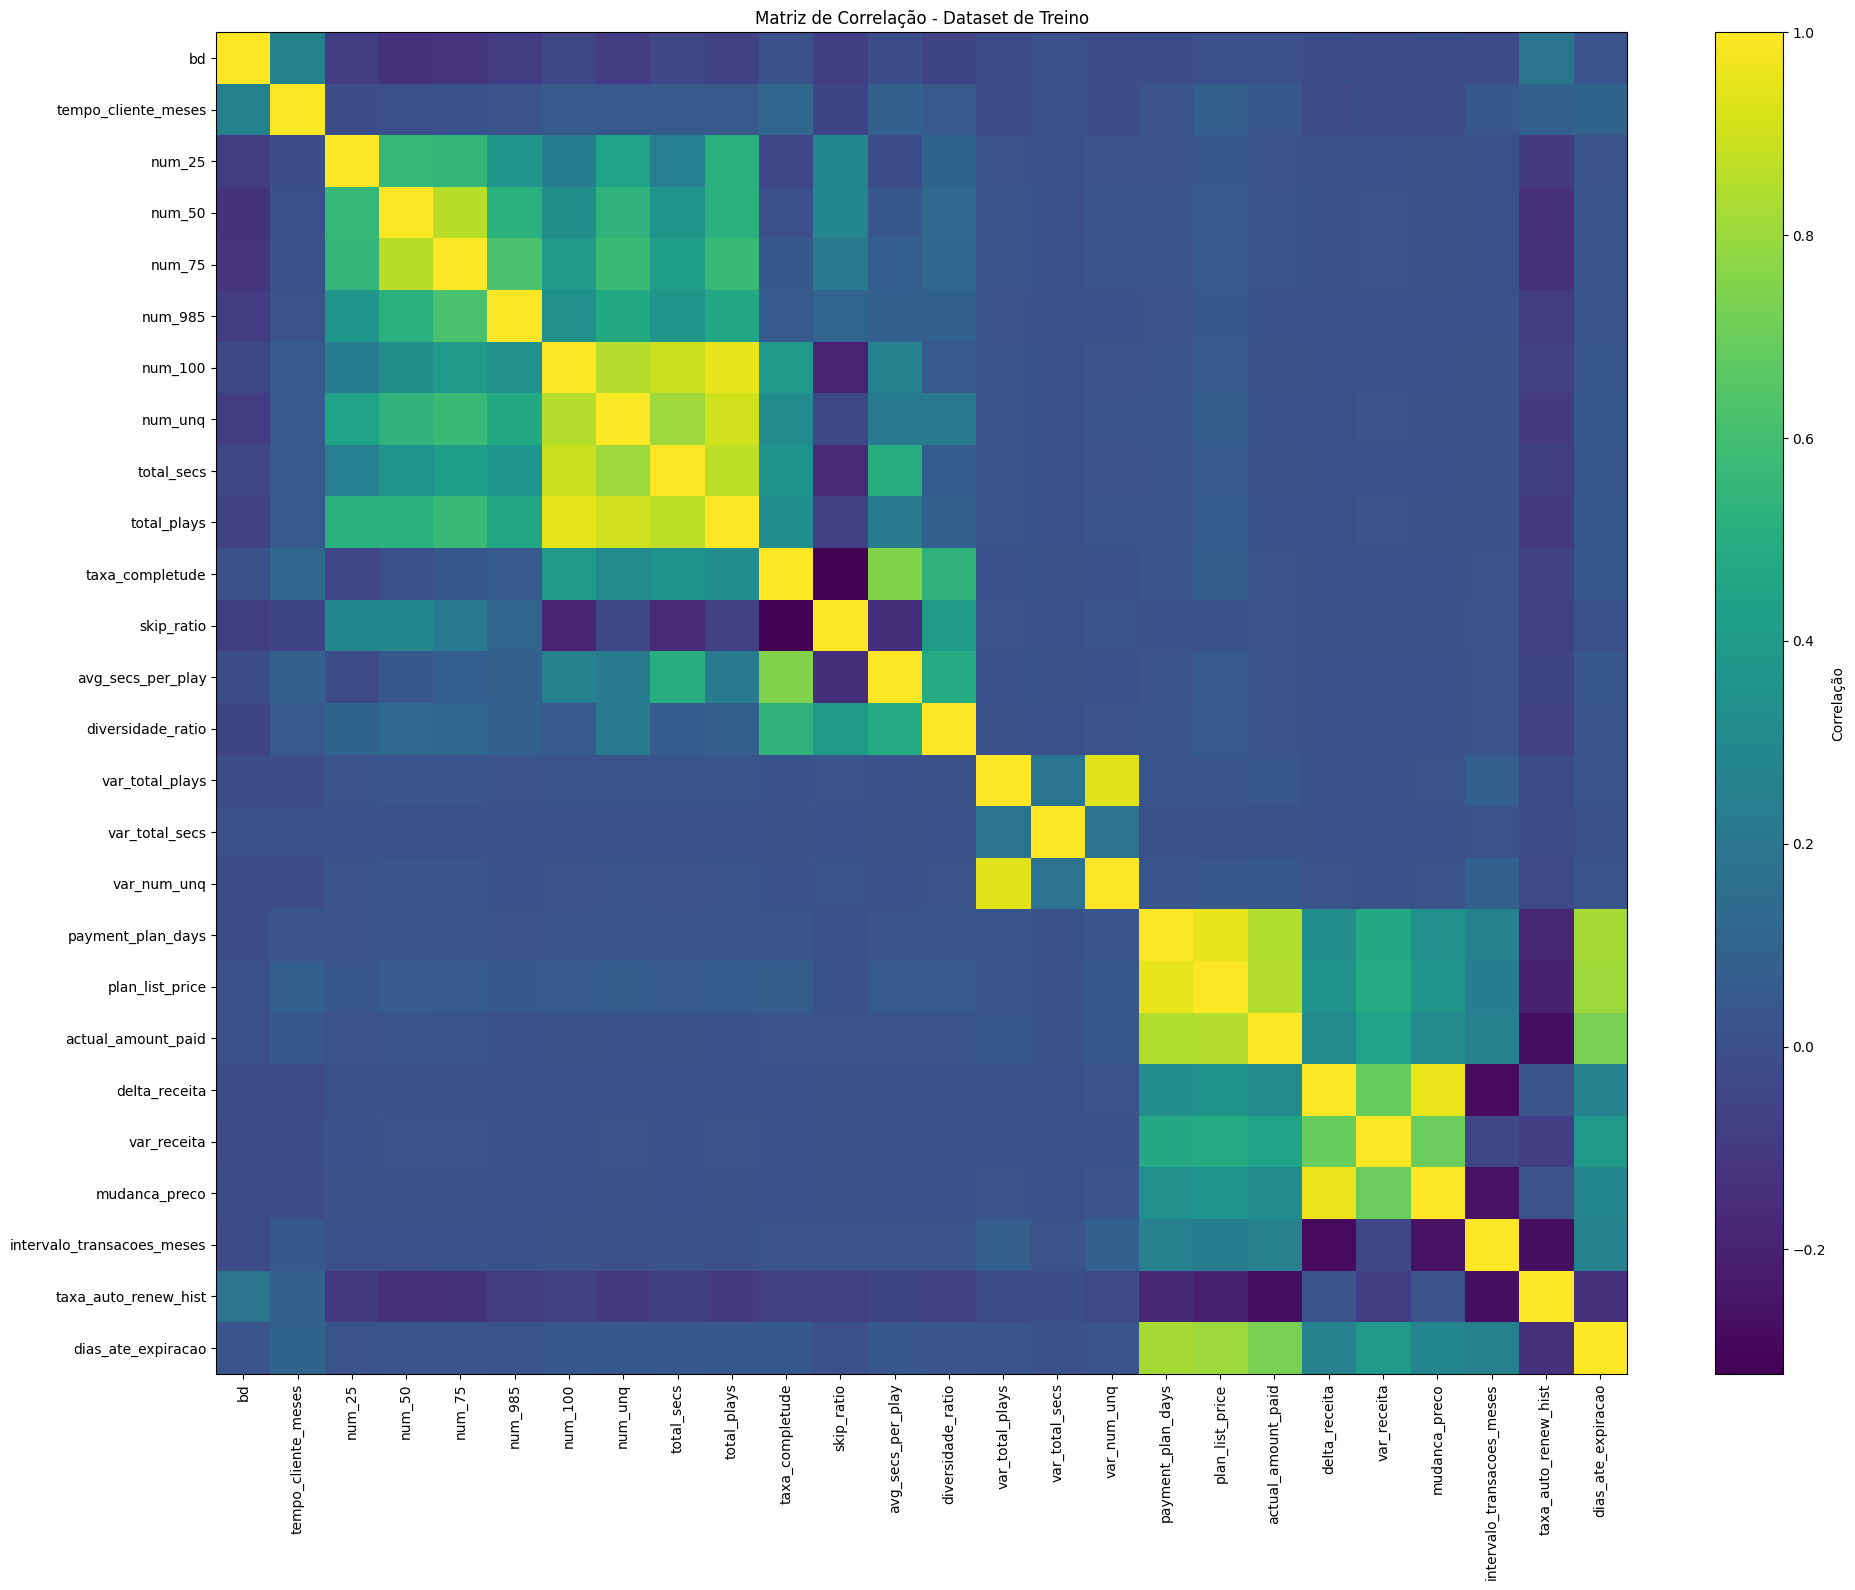

In [ ]:
pdf_corr = pd.DataFrame(
    matriz_corr_np,
    index=colunas_corr,
    columns=colunas_corr
)

plt.figure(figsize=(20, 16))

plt.imshow(
    pdf_corr,
    aspect="auto"
)

plt.colorbar(label="Correlação")

plt.xticks(
    range(len(pdf_corr.columns)),
    pdf_corr.columns,
    rotation=90
)

plt.yticks(
    range(len(pdf_corr.index)),
    pdf_corr.index
)

plt.title("Matriz de Correlação - Dataset de Treino")

plt.tight_layout()
plt.show()

### Define Correlations

In [ ]:
pares_correlacionados = []

for i in range(len(colunas_corr)):
    for j in range(i + 1, len(colunas_corr)):

        corr = matriz_corr_np[i, j]

        if abs(corr) >= 0.80:
            pares_correlacionados.append(
                (
                    colunas_corr[i],
                    colunas_corr[j],
                    corr
                )
            )

pdf_pares = pd.DataFrame(
    pares_correlacionados,
    columns=[
        "feature_1",
        "feature_2",
        "correlacao"
    ]
).sort_values(
    "correlacao",
    key=lambda x: x.abs(),
    ascending=False
)



pdf_pares["abs_correlacao"] = pdf_pares["correlacao"].abs()

pdf_pares["categoria_correlacao"] = pd.cut(
    pdf_pares["abs_correlacao"],
    bins=[-np.inf, 0.30, 0.50, 0.70, 0.90, np.inf],
    labels=[
        "Muito baixa",
        "Baixa",
        "Moderada",
        "Alta",
        "Muito alta"
    ]
)

pdf_pares["categoria_selecao"] = np.select(
    [
        pdf_pares["abs_correlacao"] >= 0.90,
        pdf_pares["abs_correlacao"] >= 0.70,
        pdf_pares["abs_correlacao"] >= 0.50
    ],
    [
        "Remover uma das features",
        "Investigar redundância",
        "Correlação moderada"
    ],
    default="Manter ambas"
)
pdf_pares

,feature_1,feature_2,correlacao,abs_correlacao,categoria_correlacao,categoria_selecao
13,delta_receita,mudanca_preco,0.96,0.96,Muito alta,Remover uma das features
8,payment_plan_days,plan_list_price,0.95,0.95,Muito alta,Remover uma das features
3,num_100,total_plays,0.95,0.95,Muito alta,Remover uma das features
7,var_total_plays,var_num_unq,0.94,0.94,Muito alta,Remover uma das features
5,num_unq,total_plays,0.90,0.90,Muito alta,Remover uma das features
2,num_100,total_secs,0.89,0.89,Alta,Investigar redundância
6,total_secs,total_plays,0.87,0.87,Alta,Investigar redundância
0,num_50,num_75,0.86,0.86,Alta,Investigar redundância
11,plan_list_price,actual_amount_paid,0.86,0.86,Alta,Investigar redundância
1,num_100,num_unq,0.85,0.85,Alta,Investigar redundância


## Correlação com o Churn

In [ ]:
def analisar_categorica_churn(df, coluna):

    return (
        df
        .groupBy(coluna)
        .agg(
            F.countDistinct("msno").alias("clientes"),

            F.sum(
                F.when(F.col("churn_m3") == 1, 1).otherwise(0)
            ).alias("churns"),

            F.round(
                F.sum(
                    F.when(F.col("churn_m3") == 1, 1).otherwise(0)
                ) / F.countDistinct("msno"),
                4
            ).alias("taxa_churn")
        )
        .orderBy(F.desc("taxa_churn"))
    )

In [ ]:
colunas_para_analise = [
    col for col in features_categoricas
    if col not in [IDENTIFY, "safra"]
]

for coluna in colunas_para_analise:

    print(f"\n{'='*60}")
    print(f"ANÁLISE: {coluna}")
    print(f"{'='*60}")

    analisar_categorica_churn(
        dfs_master_train,
        coluna
    ).show(50, truncate=False)


ANÁLISE: city
+----+--------+------+----------+
|city|clientes|churns|taxa_churn|
+----+--------+------+----------+
|11  |13927   |14972 |1.075     |
|15  |70126   |73857 |1.0532    |
|22  |67005   |66217 |0.9882    |
|9   |18298   |17942 |0.9805    |
|18  |12471   |12083 |0.9689    |
|6   |40833   |39477 |0.9668    |
|17  |8180    |7806  |0.9543    |
|10  |10641   |10148 |0.9537    |
|14  |32126   |30619 |0.9531    |
|7   |3889    |3669  |0.9434    |
|13  |160368  |147998|0.9229    |
|8   |12542   |11532 |0.9195    |
|21  |8930    |8171  |0.915     |
|5   |119076  |107286|0.901     |
|4   |77808   |69723 |0.8961    |
|12  |19320   |17227 |0.8917    |
|3   |8207    |7006  |0.8537    |
|20  |1079    |899   |0.8332    |
|16  |1481    |1229  |0.8298    |
|19  |211     |138   |0.654     |
|1   |479598  |213295|0.4447    |
+----+--------+------+----------+


ANÁLISE: gender
+-------+--------+------+----------+
|gender |clientes|churns|taxa_churn|
+-------+--------+------+----------+
|femal

In [ ]:
%%time
colunas_com_target = colunas_corr + ["churn_m3"]

df_corr_target = dfs_master_train.select(*colunas_com_target)

correlacoes_target = []

for c in colunas_corr:

    corr = df_corr_target.stat.corr(
        c,
        "churn_m3"
    )

    correlacoes_target.append(
        (c, corr)
    )

pdf_target = pd.DataFrame(
    correlacoes_target,
    columns=["feature", "correlacao_churn"]
).sort_values(
    "correlacao_churn",
    key=lambda x: x.abs(),
    ascending=False
)

pdf_target

CPU times: user 27 ms, sys: 1.4 ms, total: 28.4 ms
Wall time: 48.9 s


,feature,correlacao_churn
19,actual_amount_paid,-0.15
24,taxa_auto_renew_hist,-0.09
25,dias_ate_expiracao,-0.07
17,payment_plan_days,-0.05
23,intervalo_transacoes_meses,0.04
0,bd,-0.04
7,num_unq,-0.03
22,mudanca_preco,-0.03
20,delta_receita,-0.03
4,num_75,-0.03


| Bloco                     | Evidência linear                           |
| ------------------------- | ------------------------------------------ |
| **Recência/atividade**    | 🟢 mais forte                              |
| **BD/tratamento**         | 🟢 relevante                               |
| **Cidade**                | 🟢 relevante, mas analisar como categórica |
| **Auto-renew**            | 🟡 moderada                                |
| **Cancelamento**          | 🟡 moderada                                |
| **Receita**               | 🟡 fraca                                   |
| **Transações**            | 🟡 fraca                                   |
| **Comportamento de uso**  | 🟡 muito fraca linearmente                 |
| **Qualidade/intensidade** | 🔴 praticamente zero linearmente           |


# Encoders

### Dummy

Uma coluna para cada categoria

In [ ]:
%%time
features_to_exclude = ['msno', 'safra']
cols_to_dummy = features_categoricas

categorias_treino = {}

for col in cols_to_dummy:

    valores = (
        dfs_train_sample
        .select(col)
        .where(F.col(col).isNotNull())
        .distinct()
        .rdd
        .map(lambda row: row[0])
        .collect()
    )

    categorias_treino[col] = valores

    print(f"\n{col}:")
    print(f"Quantidade de categorias: {len(valores)}")
    print(valores)


city:
Quantidade de categorias: 21
['7', '15', '11', '3', '8', '22', '16', '5', '18', '17', '6', '19', '9', '1', '20', '10', '4', '12', '13', '14', '21']

gender:
Quantidade de categorias: 3
['unknown', 'female', 'male']

registered_via:
Quantidade de categorias: 4
['7', '3', '9', '4']

payment_method_id:
Quantidade de categorias: 34
['15', '11', '29', '3', '30', '34', '8', '28', '22', '35', '16', '31', '18', '27', '17', '26', '6', '19', '41', '23', '38', '40', '33', 'missing', '32', '20', '36', '10', '37', '39', '12', '13', '21', '14']

perfil_volume:
Quantidade de categorias: 4
['medio', 'muito_alto', 'alto', 'baixo']

perfil_frequencia:
Quantidade de categorias: 2
['raro', 'sem_atividade']

perfil_consumo:
Quantidade de categorias: 4
['rare', 'casual_sporadic', 'heavy_sporadic', 'sem_atividade']

perfil_engajamento:
Quantidade de categorias: 3
['engajamento_medio', 'baixo_engajamento', 'alto_engajamento']

tempo_escuta_categoria:
Quantidade de categorias: 3
['curta', 'media', 'long

In [ ]:
%%time
def criar_dummies(df, categorias_treino):
    """
    Cria dummies 0/1 usando exclusivamente as categorias
    definidas no TRAIN.

    As dummies são criadas em um único SELECT,
    evitando uma sequência de withColumn().
    """

    # Colunas que permanecerão no DataFrame
    colunas_base = [
        F.col(c)
        for c in df.columns
        if c not in categorias_treino
    ]

    # Todas as dummies
    colunas_dummies = []

    for coluna, categorias in categorias_treino.items():

        for categoria in categorias:

            nome_dummy = f"{coluna}_{categoria}"

            colunas_dummies.append(
                F.when(
                    F.col(coluna) == F.lit(categoria),
                    F.lit(1)
                )
                .otherwise(F.lit(0))
                .alias(nome_dummy)
            )


    return df.select(
        *colunas_base,
        *colunas_dummies
    )

CPU times: user 7 µs, sys: 0 ns, total: 7 µs
Wall time: 9.3 µs


In [ ]:
%%time
dfs_master_train_dummy = criar_dummies(
    dfs_train_sample,
    categorias_treino
)


dfs_test_dummy = criar_dummies(
    dfs_master_test,
    categorias_treino
)

dfs_validacao_dummy = criar_dummies(
    dfs_master_validacao,
    categorias_treino
)

CPU times: user 357 ms, sys: 88.5 ms, total: 446 ms
Wall time: 953 ms


### Save In Drive

In [ ]:
%%time
dfs_master_train_dummy.write.mode("overwrite").parquet("/content/drive/MyDrive/SANTANDER/train_encoded.parquet")

dfs_test_dummy.write.mode("overwrite").parquet("/content/drive/MyDrive/SANTANDER/test_encoded.parquet")

dfs_validacao_dummy.write.mode("overwrite").parquet("/content/drive/MyDrive/SANTANDER/validation_encoded.parquet")

CPU times: user 24.5 ms, sys: 6.7 ms, total: 31.2 ms
Wall time: 2min 42s


In [ ]:
%%time
dfs_master_train_dummy.describe().show()

+-------+--------------------+------------------+------------------+-------------------+-------------------+------------------+------------------+------------------+------------------+------------------+-----------------+-------------------+------------------+-----------------+------------------+-------------------+------------------+-------------------+-------------------+------------------+-------------------+---------------------+-------------------+------------------+--------------------+------------------+-----------------+------------------+------------------+--------------------+-----------------------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------------+-------------------+--------------------+---------------------+----------------------------+---------------------------+------------------------+------------------+-------------------+--------------------+-------------------+--------------------+------